In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.iea22s import IEA22s
from utils.sites import Hornsrev1Site

# this is a smoother version of PyWake IEA22 that works better with wake steering optimization
wt = IEA22s()
wds = np.arange(0, 360, 2)
wss = np.arange(3, 25, 1)  # we don't really need all this range
(x, y), site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
TI = 0.04  # site.local_wind().TI_ilk.ravel()

In [3]:
from utils.easy import easy_yaw_gnn
# this should work with PyWake-style inputs
yaws = easy_yaw_gnn(x, y, wd=wds, ws=wss, TI=TI)

/tmp/dgodi_3883152_hyd/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Converting to graphs:   0%|          | 0/3960 [00:00<?, ?it/s]

  0%|          | 0/3960 [00:00<?, ?it/s]

generated 3960 graphs from 3960 cases
Number of trainable parameters: 1450241
Evaluating model models/best.pt


/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

In [4]:
# try yaw on PyWake
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=0, tilt=0, n_cpu=16)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=yaws, tilt=0, n_cpu=16)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f'AEP uplift: {uplift:.2f}%')

Converting to graphs:   0%|          | 0/3960 [00:29<?, ?it/s]


8263.395422082358
8343.64846110192
AEP uplift: 0.97%


In [5]:
# plot look-up-table based on predictions

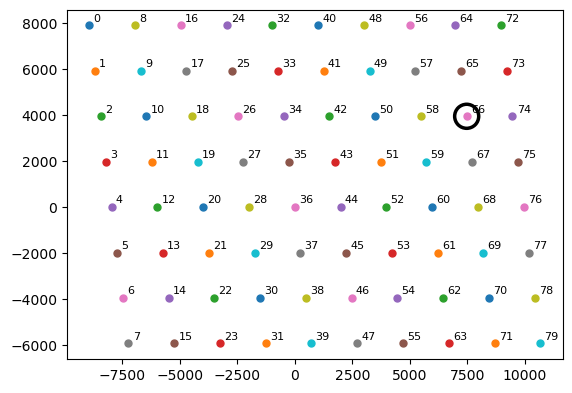

In [6]:
# visualize wind farm to see which turbine we pick

import matplotlib.pyplot as plt

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
turbine_idx = int(66)

plt.scatter(
    x[turbine_idx],
    y[turbine_idx],
    marker="o",
    facecolors="none",
    edgecolors="k",
    linewidths=2.5,
    s=300
)
plt.show()

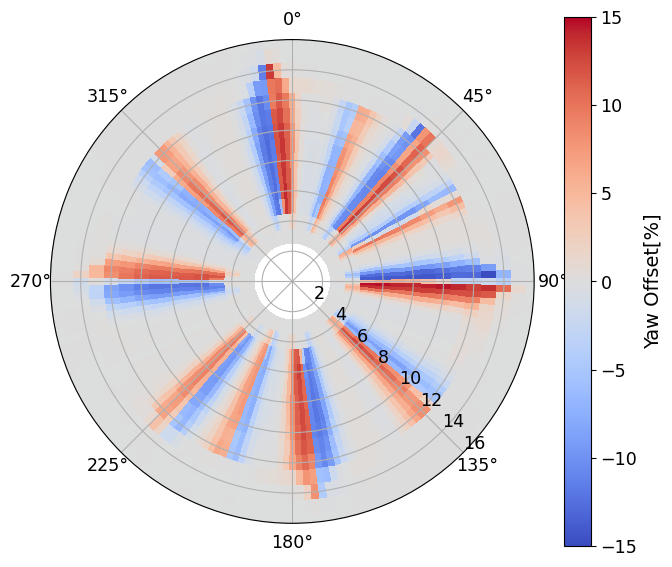

In [7]:
from utils.plot_utils import lut_3d_heatmap

lut_3d_heatmap(yaws[turbine_idx, :, :], wds=wds, wss=wss)  # turbine 0